In [1]:
import random
random.seed(42)
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
#import bcolz
import pandas
import allel; print('scikit-allel', allel.__version__)
%reload_ext memory_profiler
from itertools import compress
from collections import *
from functools import reduce
import pandas as pd
import numpy as np

scikit-allel 1.3.5


In [6]:
def plot_pca_coords(coords, model, pc1, pc2, ax, sample_population):
    sns.despine(ax=ax, offset=5)
    x = coords[:, pc1]
    y = coords[:, pc2]
    for pop in populations:
        flt = (sample_population == pop)
        ax.plot(x[flt], y[flt], marker='o', linestyle=' ', color=pop_colours[pop], 
                label=pop, markersize=6, mec='k', mew=.5)
    ax.set_xlabel('PC%s (%.1f%%)' % (pc1+1, model.explained_variance_ratio_[pc1]*100))
    ax.set_ylabel('PC%s (%.1f%%)' % (pc2+1, model.explained_variance_ratio_[pc2]*100))
    

def fig_pca(coords, model, title, sample_population=None):
    if sample_population is None:
        sample_population = df_samples.population.values
    # plot coords for PCs 1 vs 2, 3 vs 4
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 2, 1)
    plot_pca_coords(coords, model, 0, 1, ax, sample_population)
    ax = fig.add_subplot(1, 2, 2)
    plot_pca_coords(coords, model, 2, 3, ax, sample_population)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()

In [5]:
def plot_pca_coords(coords, model, pc1, pc2, ax, sample_population):
    sns.despine(ax=ax, offset=5)
    x = coords[:, pc1]
    y = coords[:, pc2]
    for pop in populations:
        flt = (sample_population == pop)
        ax.plot(x[flt], y[flt], marker='o', linestyle=' ', color=pop_colours[pop], 
                label=pop, markersize=6, mec='k', mew=.5)
    ax.set_xlabel('PC%s (%.1f%%)' % (pc1+1, model.explained_variance_ratio_[pc1]*100))
    ax.set_ylabel('PC%s (%.1f%%)' % (pc2+1, model.explained_variance_ratio_[pc2]*100))
    

def fig_pca(coords, model, title, sample_population=None):
    if sample_population is None:
        sample_population = df_samples.population.values
    # plot coords for PCs 1 vs 2, 3 vs 4
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 2, 1)
    plot_pca_coords(coords, model, 0, 1, ax, sample_population)
    ax = fig.add_subplot(1, 2, 2)
    plot_pca_coords(coords, model, 2, 3, ax, sample_population)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    
def window_GT(callset, window, mode="SNP", start=0, step=None):
    '''
    split the genotype into windows based on the num of SNPs or physical chromosome position.
    default start from 0
    '''
    genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
    if mode == "SNP":
        while start < len(genotype) - window:
            start += window 
            gt_subset = genotype[start : start + window]
            yield gt_subset 
        else:
            gt_subset = genotype[start : ] #final should be 31497110
            yield gt_subset
            
    elif mode == "BP":
        start = 0
        end = start + 100
        med = (start + end) / 2
        pos_dict = defaultdict(list)
        for i in pos:
            #filter(lambda x: x not in subset_of_A, A)
            if end > i > start:
                pos_dict[med].append(i)
                #print("process 1 " + str(i))
            else:
                while i >= end:
                    start += 100
                    end  += 100
                    med = (start + end) / 2
            pos_dict[med].append(i) if i not in pos_dict[med] else pos_dict[med]
            
        # temp pos of pos array
        temp_pos = 0 
        for k,v in pos_dict.items():
            temp_pos_start = temp_pos
            temp_pos_end = temp_pos_start + len(v)
            temp_pos = len(v)
            gt_subset_BP = genotype[temp_pos_start : temp_pos_end]
            yield gt_subset_BP
            
    else:
        print("please specify the mode of sliding window: mode = ['SNP', 'BP']")

# # do window-based PCA
# for i in window_GT(g, 100):
#     flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)#biallelic
#     gf = i.compress(flt, axis=0)
#     gn = gf.to_n_alt() 

In [6]:
pop_colours = {
    'QuH': 'red',
    'QuL': 'blue',
}

In [14]:
callset

In [16]:
# read vcf file and make genotype matrix
# callset = allel.read_vcf("/Volumes/LaCie/localPCA/Quare/Quare.LG7.vcf.gz")
# chrom = 'LG7'
# start = 32371769# -> see 1.HMM start = int(data.iloc[0]['start'])
# end = 33905450 # -> see 1.HMM end = int(data.iloc[-1]['end'])
# # start: 32371769, end:  33905450
# callset = allel.read_vcf("/Volumes/LaCie/localPCA/Quare/Quare.LG7.vcf.gz", region="{}:{}-{}".format(chrom, start, end))
# # population 
POP='Quare'
vcf_path = "/Volumes/LaCie/localPCA/{}/".format(POP)
# POP = "YAL"
CHROM = "LG7"
vcffile = "/Volumes/LaCie/localPCA/Quare/Quare.LG7.vcf.gz"
#chrom = "LR880645.1" # chromosome 1
chrom = "LR8806{}.1".format(44 + int(CHROM.split("LG")[1])) # 44 + chromosome ID
start = 32371769# -> see 1.HMM start = int(data.iloc[0]['start'])
end = 33905450 # -> see 1.HMM end = int(data.iloc[-1]['end'])
# start: 32371769, end:  33905450
callset = allel.read_vcf(vcffile, region="{}:{}-{}".format(chrom, start, end))


df_samples = pandas.read_csv('/Users/rainlam/Project/3.SV/pca_result/pop.txt', delimiter='\t')
df_samples.head()
sample_size = len(callset["samples"])
pop = df_samples.population.unique()
pop_colours = {
    'QuH': 'red',
    'QuL': 'blue',
}
# fisrt eigenvector stored in a dictionary {med_pos: first_eigen_vector}
##### maybe matrix???? 
#coord_dict = defaultdict(list)

#coord_matrix = np.zeros((5018, 42))
# output matrix should look like this  
# sample  1st_eigenvector  2nd_eigenvector  3rd_eigenvector  4th_eigenvector   mid  
# indv1      1.1               1.2              1.3              1.4          1932
# indv2      1.1               1.2              1.3              1.4          1932
# indv3      1.1               1.2              1.3              1.4          1932
# indv4      1.1               1.2              1.3              1.4          1932
# indv5      1.1               1.2              1.3              1.4          1932
#  ...
#
# indv40    1.2               1.5              1.4              1.7          1932


count = 0 
start = 0
window = 100 # 100 SNPs
end = start + window

rows = 20
cols = 10 
coord_matrix = callset['samples']
# samples 
samples = callset['samples']
sample_size = len(samples)
#empty array, shape(0,12)
start_array = np.empty((0, 12))

#write into matrix
for subset_gt in window_GT(callset, window, "SNP", start=0, step=None):
    subset_gt_start = start
    subset_gt_end = subset_gt_start + len(subset_gt) 
    ac = subset_gt.count_alleles()[:] 
    flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1) # SNP filtering and only keep biallelic 
    gf = subset_gt.compress(flt, axis=0) # actual SNP filterings
    gn = gf.to_n_alt() #convert genotype data into...
    # actual postion 
    chrom_pos = list(compress(callset["variants/POS"][subset_gt_start:subset_gt_end], flt)) # actual chromosome postion
    chrom_pos_mean = np.ones(sample_size) + (sum(chrom_pos) / len(chrom_pos)) #med of chromosome postion
    coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')
    #coords1.shape (40, 10)
    #fisrt_eigenvector = coords1[:, 0] # pc1 coords1.components_[:,1]
    #second_eigenvector = coords1[:, 1] # pc2 coords1.components_[:,1]
    tmp_array = np.column_stack((samples, chrom_pos_mean, coords1)) # 列加
    # final_array = np.append(final_array, tmp_array, axis=0)     
    # new start
    start_array = np.append(start_array, tmp_array, axis=0)
    start += window
    
# sample  1st_eigenvector  2nd_eigenvector  3rd_eigenvector  4th_eigenvector   mid  
# indv1      1.1               1.2              1.3              1.4          1932
# indv2      1.1               1.2              1.3              1.4          1932
# indv3      1.1               1.2              1.3              1.4          1932
# indv4      1.1               1.2              1.3              1.4          1932
# indv5      1.1               1.2              1.3              1.4          1932
#  ...
#
# indv40    1.2               1.5              1.4              1.7          1932

    
# # count alleles 
# ac = g.count_alleles()[:]
# # SNP filtering and only keep biallelic 
# flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
# gf = g.compress(flt, axis=0)
# gn = gf.to_n_alt()
# multiallelic
# np.count_nonzero(ac.max_allele() > 1)
# biallelic singletons
# np.count_nonzero((ac.max_allele() == 1) & ac.is_singleton(1))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


In [17]:
gn

array([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
        1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1

Text(0.5, 0, 'Quare LG1 (Mb)')

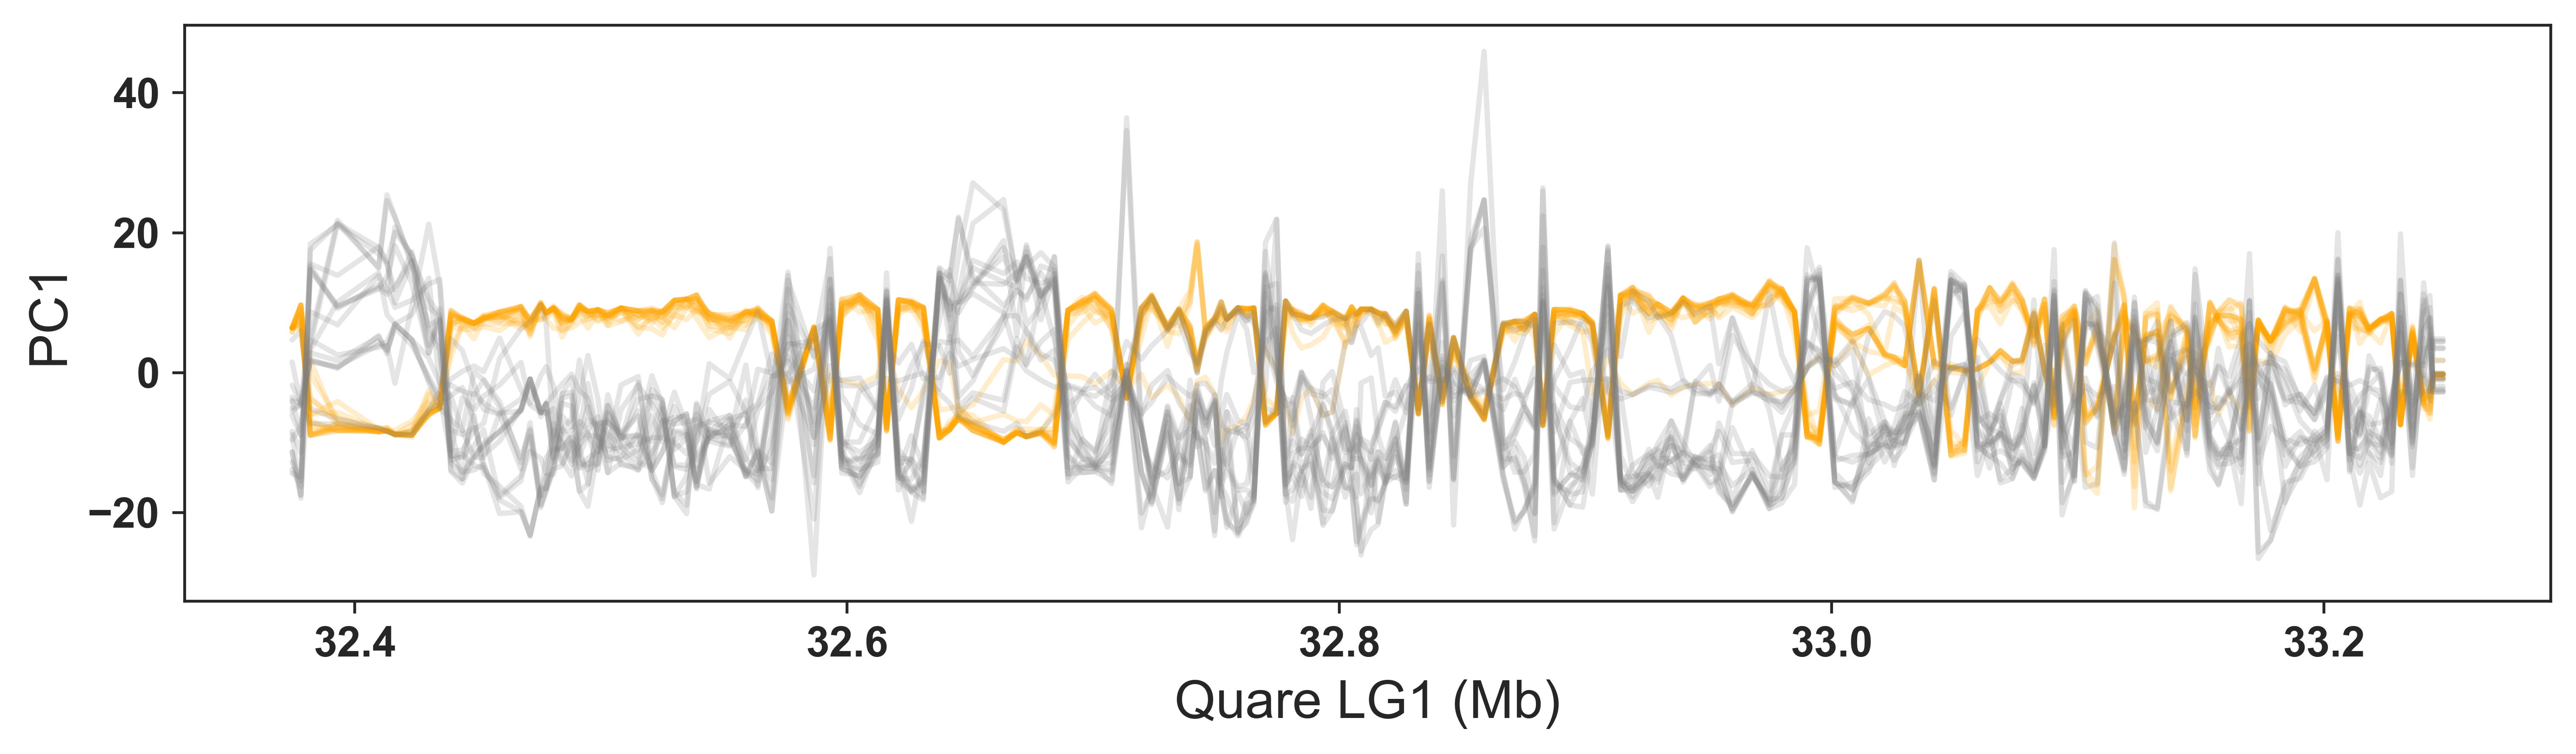

In [20]:
plt.figure(figsize=(12, 3), dpi=600)
df = pd.DataFrame(start_array)
for i in list(df_samples["sample"]):
    new_df = df[df[0] == i]
    if "L" in i:
        #continue
        plt.plot(new_df[1]/1e6, new_df[2], "orange", alpha=0.2)
    else:
        plt.plot(new_df[1]/1e6, new_df[2], "grey",alpha=0.2)
#         pass

# plt.xlim(0,6)
plt.xticks(fontweight="bold", fontsize=12)
plt.yticks(fontweight="bold", fontsize=12)
plt.ylabel("PC1", fontsize=15)
plt.xlabel("Quare LG1 (Mb)", fontsize=15)

Text(0.5, 0, 'Quare LG7 (Mb)')

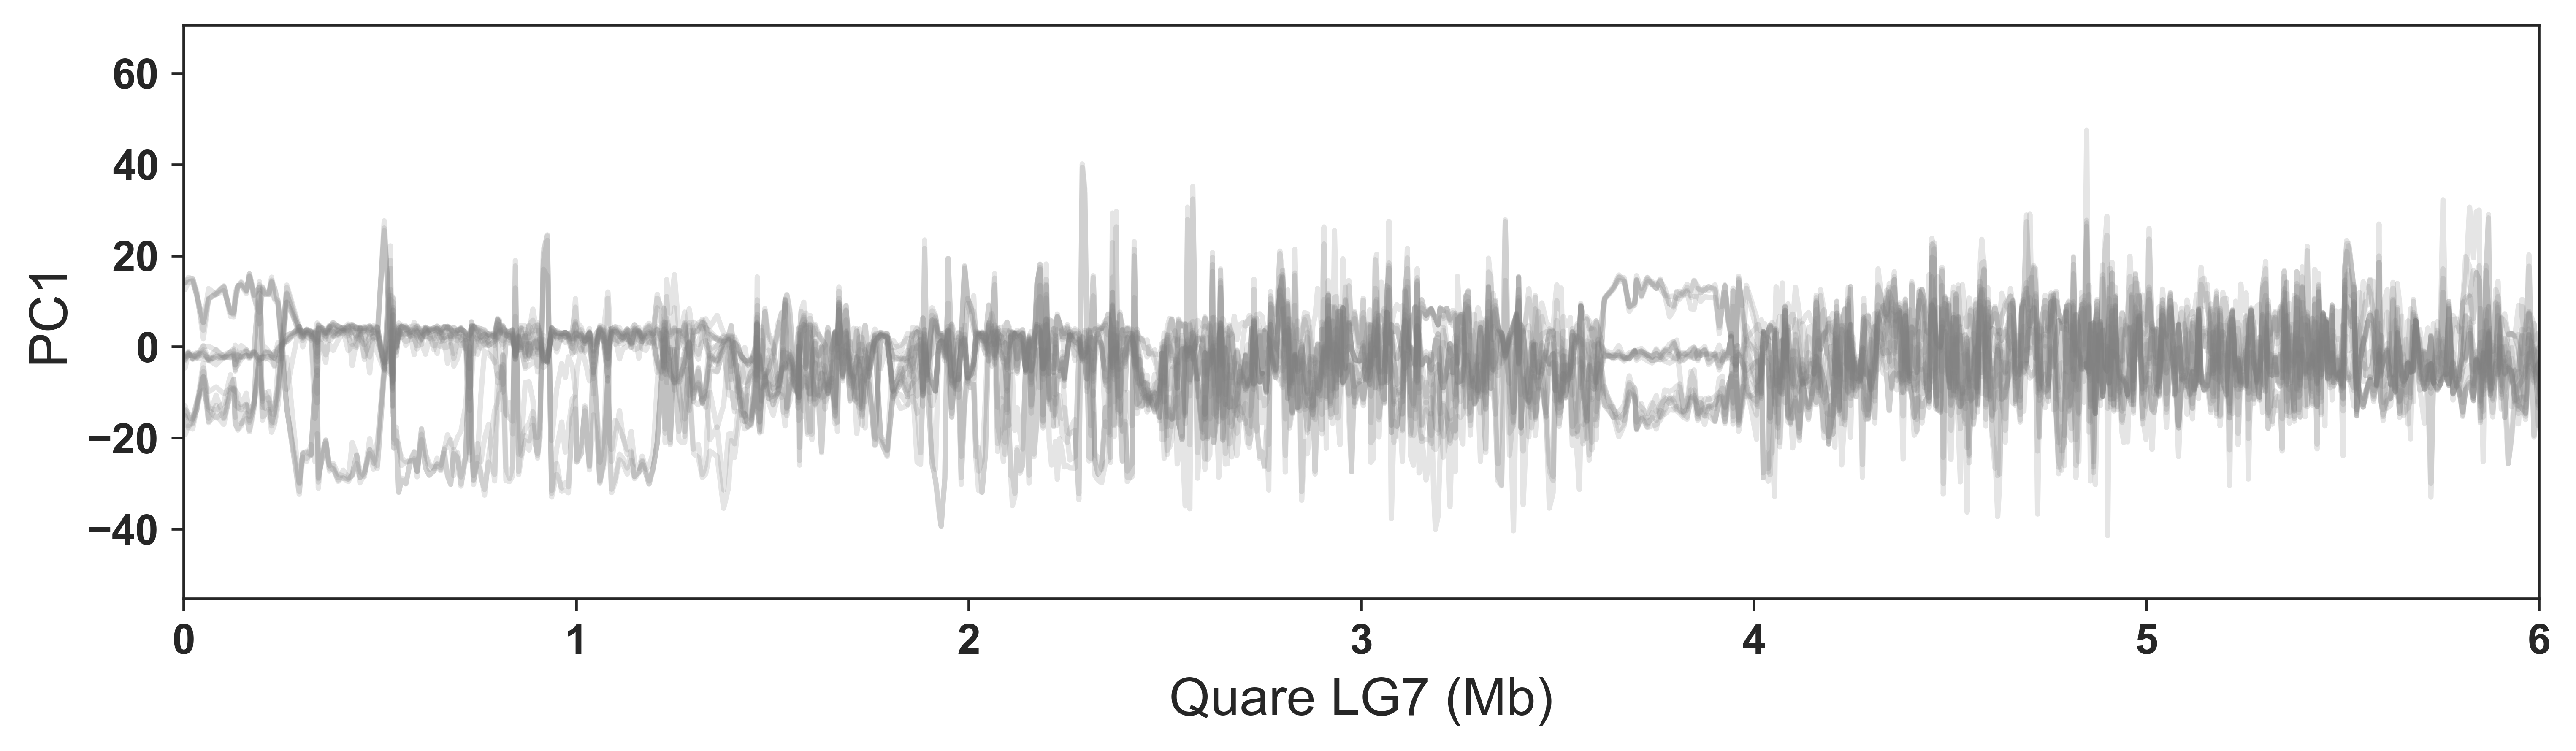

In [11]:
plt.figure(figsize=(12, 3), dpi=600)
df = pd.DataFrame(start_array)
for i in list(df_samples["sample"]):
    new_df = df[df[0] == i]
    if "L" in i:
        continue
        #plt.plot(new_df[1]/1e6, new_df[3], "orange", alpha=0.2)
    else:
        plt.plot(new_df[1]/1e6, new_df[2], "grey",alpha=0.2)
    

plt.xlim(0,6)
plt.xticks(fontweight="bold", fontsize=12)
plt.yticks(fontweight="bold", fontsize=12)
plt.ylabel("PC1", fontsize=15)
plt.xlabel("Quare LG7 (Mb)", fontsize=15)

In [107]:
#model1.components_

In [335]:
#coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')

In [310]:
tmp_array[-1]

array(['ArL-M11', 31491276.535714287, -2.996410608291626,
       0.5200203657150269, 2.6417717933654785, -0.02720353566110134,
       0.2412671446800232, 0.6672487258911133, 0.19312426447868347,
       -0.23758558928966522, 0.9426175951957703, 0.821645975112915],
      dtype=object)

In [312]:
start_array[-1]

array(['ArL-M11', 31491276.535714287, -2.996410608291626,
       0.5200203657150269, 2.6417717933654785, -0.02720353566110134,
       0.2412671446800232, 0.6672487258911133, 0.19312426447868347,
       -0.23758558928966522, 0.9426175951957703, 0.821645975112915],
      dtype=object)

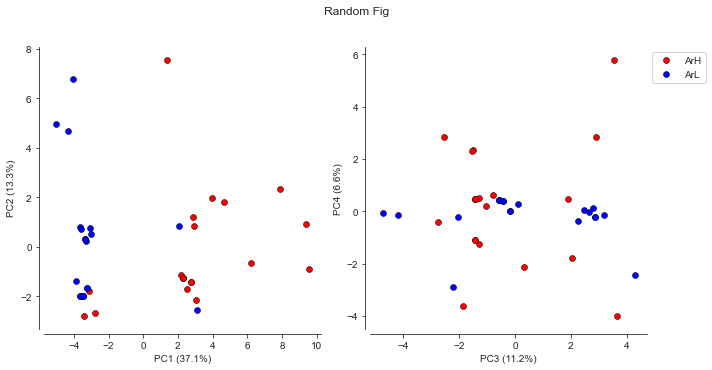

In [322]:
fig_pca(coords1, model1, "Random Fig")

In [68]:
start = 0
end = start + 100
med = (start + end) / 2
pos_dict = defaultdict(list)
for i in pos_dict:
    #filter(lambda x: x not in subset_of_A, A)
    if end > i > start:
        pos_dict[med].append(i)
        #print("process 1 " + str(i))
    else:
        while i >= end:
            start += 100
            end  += 100
            med = (start + end) / 2
    pos_dict[med].append(i) if i not in pos_dict[med] else pos_dict[med]

pos_dict

defaultdict(list, {})

In [355]:
model1.components_

array([[ 8.7499962e-04, -3.2698265e-03,  2.3331030e-03, ...,
        -1.1941617e-03, -1.1941617e-03,  1.6851902e-03],
       [-8.7541330e-04,  1.0207704e-03, -3.5119858e-03, ...,
         3.1166198e-04,  3.1166198e-04, -3.3726715e-03],
       [-4.6694322e-04, -2.9046674e-05,  1.2075589e-03, ...,
         3.7298593e-04,  3.7298593e-04, -1.5728096e-03],
       ...,
       [-2.4530208e-03, -9.7339053e-04, -3.2551584e-04, ...,
        -3.2072587e-04, -3.2072587e-04, -1.5025584e-03],
       [ 2.8162494e-03,  2.2458671e-04,  8.6000905e-04, ...,
         8.0296845e-04,  8.0296845e-04,  2.0460689e-03],
       [ 1.7602780e-03,  2.7312476e-03, -1.0945030e-03, ...,
        -2.7296116e-04, -2.7296116e-04, -9.1939553e-04]], dtype=float32)

In [ ]:
# ##############################################################################
# ############# keep this in case you want to do LD pruning later ##############
# ##############################################################################

# def ld_prune(gn, size, step, threshold=.1, n_iter=1):
#     '''
#     LD pruning
#     '''
#     for i in range(n_iter):
#         loc_unlinked = allel.locate_unlinked(gn, size=size, step=step, threshold=threshold)
#         n = np.count_nonzero(loc_unlinked)
#         n_remove = gn.shape[0] - n
#         print('iteration', i+1, 'retaining', n, 'removing', n_remove, 'variants')
#         gn = gn.compress(loc_unlinked, axis=0)
#     return gn

# def plot_ld(gn, title):
#     '''
#     plot LD
#     '''
#     m = allel.rogers_huff_r(gn) ** 2
#     ax = allel.plot_pairwise_ld(m)
#     ax.set_title(title)

In [170]:

def window_GT(callset, window, mode="SNP", start=0, step=None):
    
    '''
    split the genotype into windows based on the num of SNPs or physical chromosome position.
    default start from 0
    '''
    genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
    count= 0
    if mode == "SNP":
        while start < len(genotype) - window:
            start += window 
            count += 1
            gt_subset = genotype[start : start + window]
            yield gt_subset 
        else: 
            gt_subset = genotype[start : ] #final should be 31497110
            yield gt_subset

In [ ]:
def window_GT_BP(callset, window_BP=100, start=0, step=None):
    '''
    split the genotype into windows based on the actual basepairs
    default start from 0 of the chromosome
    step function has implemented yet
    '''
    # list(compress(callset["variants/POS"], flt)) 
    pos = callset["variants/POS"]
    genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
    # split genotype data into chunks
    # return dictionary into {mediate_pos:[pos1, pos2, pos3, pos4...]}
    start = 0
    end = start + 100
    med = (start + end) / 2
    pos_dict = defaultdict(list)
    for i in pos:
        # filter(lambda x: x not in subset_of_A, A)
        if end > i > start:
            pos_dict[med].append(i)
            # print("process 1 " + str(i))
        else:
            while i >= end:
                start += 100
                end  += 100
                med = (start + end) / 2
        pos_dict[med].append(i) if i not in pos_dict[med] else pos_dict[med]
    # temp pos of pos array
    temp_pos = 0 
    for k,v in pos_dict.items():
        temp_pos_start = temp_pos
        temp_pos_end = temp_pos_start + len(v)
        temp_pos = len(v)
        gt_subset_BP = genotype[temp_pos_start : temp_pos_end]
        yield gt_subset_BP 

In [ ]:
# read vcf file and make genotype matrix
#callset = allel.read_vcf("/Users/rainlam/Project/3.SV/localPCA/local_pca/templated/data/Aripo.LG4.vcf.gz")
callset = allel.read_vcf("/Users/rainlam/QUL/QUL.LG1.vcf.gz")
# population 
#df_samples = pandas.read_csv('/Users/rainlam/Project/3.SV/pca_result/pop.txt', delimiter='\t')
df_samples = pandas.read_csv("/Users/rainlam/QUL/QUL.pop",delimiter='\t')
df_samples.head()
sample_size = 40
pop = df_samples.population.unique()
pop_colours = {
    'female': 'red',
    'male': 'blue'
}
# fisrt eigenvector stored in a dictionary {med_pos: first_eigen_vector}
##### maybe matrix???? 
#coord_dict = defaultdict(list)

#coord_matrix = np.zeros((5018, 42))
# output matrix should look like this  
# sample  1st_eigenvector  2nd_eigenvector  3rd_eigenvector  4th_eigenvector   mid  
# indv1      1.1               1.2              1.3              1.4          1932
# indv2      1.1               1.2              1.3              1.4          1932
# indv3      1.1               1.2              1.3              1.4          1932
# indv4      1.1               1.2              1.3              1.4          1932
# indv5      1.1               1.2              1.3              1.4          1932
#  ...
#
# indv40    1.2               1.5              1.4              1.7          1932


count = 0 
start = 0
window = 100 # 100 SNPs
end = start + window

rows = 40
cols = 10 
coord_matrix = callset['samples']
# samples 
samples = callset['samples']
sample_size = len(samples)
#empty array, shape(0,12)
start_array = np.empty((0, 12))

#write into matrix
for subset_gt in window_GT(callset, window, "SNP", start=0, step=None):
    subset_gt_start = start
    subset_gt_end = subset_gt_start + len(subset_gt) 
    ac = subset_gt.count_alleles()[:] 
    flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1) # SNP filtering and only keep biallelic 
    gf = subset_gt.compress(flt, axis=0) # actual SNP filterings
    gn = gf.to_n_alt() #convert genotype data into...
    # actual postion 
    chrom_pos = list(compress(callset["variants/POS"][subset_gt_start:subset_gt_end], flt)) # actual chromosome postion
    chrom_pos_mean = np.ones(sample_size) + (sum(chrom_pos) / len(chrom_pos)) #med of chromosome postion
    coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')
    #coords1.shape (40, 10)
    #fisrt_eigenvector = coords1[:, 0] # pc1 coords1.components_[:,1]
    #second_eigenvector = coords1[:, 1] # pc2 coords1.components_[:,1]
    tmp_array = np.column_stack((samples, chrom_pos_mean, coords1)) # 列加
    # final_array = np.append(final_array, tmp_array, axis=0)     
    # new start
    start_array = np.append(start_array, tmp_array, axis=0)
    start += window
    
# sample  1st_eigenvector  2nd_eigenvector  3rd_eigenvector  4th_eigenvector   mid  
# indv1      1.1               1.2              1.3              1.4          1932
# indv2      1.1               1.2              1.3              1.4          1932
# indv3      1.1               1.2              1.3              1.4          1932
# indv4      1.1               1.2              1.3              1.4          1932
# indv5      1.1               1.2              1.3              1.4          1932
#  ...
#
# indv40    1.2               1.5              1.4              1.7          1932

    
# # count alleles 
# ac = g.count_alleles()[:]
# # SNP filtering and only keep biallelic 
# flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
# gf = g.compress(flt, axis=0)
# gn = gf.to_n_alt()
# multiallelic
# np.count_nonzero(ac.max_allele() > 1)
# biallelic singletons
# np.count_nonzero((ac.max_allele() == 1) & ac.is_singleton(1))